# Clase 02. Manipulación de datos con Pandas e inicio del análisis exploratorio

**INF-396 Introducción a la Ciencia de Datos**
Universidad Técnica Federico Santa María, Departamento de Informática

Unidades del programa: herramientas de apoyo y U2, Análisis Exploratorio de Datos (parte 1).

## Qué vamos a lograr hoy

Al terminar esta clase usted debería ser capaz de:

1. Cargar un archivo de datos reales y describir su estructura.
2. Seleccionar filas y columnas, y filtrar con condiciones.
3. Reconocer los datos faltantes y decidir qué hacer con ellos.
4. Resumir la información agrupando por categorías.
5. Combinar dos tablas con `merge`.
6. Calcular medidas de resumen y explicar por qué el promedio a veces engaña.

## Los datos de hoy

Trabajaremos con las **emisiones al aire de fuentes puntuales del año 2020**, del
Registro de Emisiones y Transferencias de Contaminantes (RETC) del Ministerio del
Medio Ambiente.

Cada fila corresponde a un contaminante emitido por un establecimiento durante 2020.
Son datos reales, con toda la suciedad que eso implica: valores faltantes, categorías
desbalanceadas y una distribución muy asimétrica.

Nos quedamos con los tres contaminantes de los planes de descontaminación atmosférica:
material particulado fino (MP2,5), material particulado respirable (MP10) y dióxido de
azufre (SO2).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 20)
sns.set_theme(style="whitegrid")

## 1. Cargar los datos y mirarlos por primera vez

La función `read_csv` lee un archivo separado por comas y devuelve un **DataFrame**,
que es la estructura central de Pandas: una tabla con filas y columnas con nombre.

In [2]:
emisiones = pd.read_csv("datos/emisiones_aire_2020.csv")
emisiones.head()

,año,empresa,establecimiento,rubro,region,provincia,comuna,latitud,longitud,tipo_fuente,combustible_primario,contaminante,cantidad_toneladas
0,2020.0,CELULOSA ARAUCO Y CONSTITUCION S A,PLANTA ARAUCO,Industria del papel y celulosa,Biobío,Arauco,Arauco,-37.206210,-73.224333,Caldera de Generación Eléctrica,Biomasa Combustible,Dióxido de azufre (SO2),NaN
1,2020.0,CELULOSA ARAUCO Y CONSTITUCION S A,PLANTA ARAUCO,Industria del papel y celulosa,Biobío,Arauco,Arauco,-37.206210,-73.224333,Caldera de Generación Eléctrica,Biomasa Combustible,Dióxido de azufre (SO2),NaN
2,2020.0,ASERRADEROS ARAUCO S A,ASERRADEROS VALDIVIA,Industria de la madera y silvicultura,Los Ríos,Valdivia,Mariquina,-39.555025,-72.908685,Caldera Industrial (Generadora de Vapor o Agua...,Gas Licuado de Petróleo,Dióxido de azufre (SO2),NaN
3,2020.0,AES GENER S A,CENTRAL TERMOELÉCTRICA LAGUNA VERDE,Termoeléctricas,Valparaíso,Valparaíso,Valparaíso,-33.102401,-71.672824,Caldera de Generación Eléctrica,Petróleo N 2 (Diesel),Dióxido de azufre (SO2),NaN
4,2020.0,AES GENER S A,CENTRAL TERMOELÉCTRICA LAGUNA VERDE,Termoeléctricas,Valparaíso,Valparaíso,Valparaíso,-33.102401,-71.672824,Caldera de Generación Eléctrica,Petróleo N 2 (Diesel),Dióxido de azufre (SO2),NaN


Antes de calcular nada, conviene responder tres preguntas: cuántos datos hay, qué
tipo tiene cada columna y qué representa una fila.

`shape` entrega la cantidad de filas y de columnas.

In [3]:
emisiones.shape

(27015, 13)

`info()` resume el tipo de dato de cada columna y cuántos valores no nulos tiene.
Es una de las primeras cosas que conviene mirar siempre.

In [4]:
emisiones.info()

<class 'pandas.DataFrame'>
RangeIndex: 27015 entries, 0 to 27014
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   año                   27015 non-null  float64
 1   empresa               27015 non-null  str    
 2   establecimiento       27015 non-null  str    
 3   rubro                 27015 non-null  str    
 4   region                27015 non-null  str    
 5   provincia             27015 non-null  str    
 6   comuna                27015 non-null  str    
 7   latitud               27003 non-null  float64
 8   longitud              27003 non-null  float64
 9   tipo_fuente           27015 non-null  str    
 10  combustible_primario  27004 non-null  str    
 11  contaminante          27015 non-null  str    
 12  cantidad_toneladas    26957 non-null  float64
dtypes: float64(4), str(9)
memory usage: 2.7 MB


Fíjese en la diferencia entre `object` (texto) y `float64` (número decimal). Esa
distinción importa: sobre una columna de texto no se puede calcular un promedio,
aunque a la vista parezca numérica.

En este archivo la columna `cantidad_toneladas` ya viene numérica, pero el archivo
original del RETC la traía como texto, porque usaba coma decimal y marcaba los datos
faltantes con un guion. El script `datos/preparar_emisiones.py` deja constancia de esa
limpieza. Es un problema muy frecuente en datos públicos chilenos y conviene tenerlo
presente.

## 2. Seleccionar columnas y filas

Para elegir una columna se usa su nombre entre corchetes. El resultado es una
**Series**, que es una columna con índice.

In [5]:
emisiones["region"].head()

0        Biobío
1        Biobío
2      Los Ríos
3    Valparaíso
4    Valparaíso
Name: region, dtype: str

Para varias columnas se pasa una lista de nombres. Note los dobles corchetes: la lista
va dentro de los corchetes de selección.

In [6]:
emisiones[["region", "comuna", "contaminante", "cantidad_toneladas"]].head()

,region,comuna,contaminante,cantidad_toneladas
0,Biobío,Arauco,Dióxido de azufre (SO2),NaN
1,Biobío,Arauco,Dióxido de azufre (SO2),NaN
2,Los Ríos,Mariquina,Dióxido de azufre (SO2),NaN
3,Valparaíso,Valparaíso,Dióxido de azufre (SO2),NaN
4,Valparaíso,Valparaíso,Dióxido de azufre (SO2),NaN


Para seleccionar filas hay dos formas que conviene no confundir:

- `iloc` selecciona por **posición**, como en una lista de Python.
- `loc` selecciona por **etiqueta** del índice, y permite además indicar columnas.

In [7]:
emisiones.iloc[0:3]

,año,empresa,establecimiento,rubro,region,provincia,comuna,latitud,longitud,tipo_fuente,combustible_primario,contaminante,cantidad_toneladas
0,2020.0,CELULOSA ARAUCO Y CONSTITUCION S A,PLANTA ARAUCO,Industria del papel y celulosa,Biobío,Arauco,Arauco,-37.206210,-73.224333,Caldera de Generación Eléctrica,Biomasa Combustible,Dióxido de azufre (SO2),NaN
1,2020.0,CELULOSA ARAUCO Y CONSTITUCION S A,PLANTA ARAUCO,Industria del papel y celulosa,Biobío,Arauco,Arauco,-37.206210,-73.224333,Caldera de Generación Eléctrica,Biomasa Combustible,Dióxido de azufre (SO2),NaN
2,2020.0,ASERRADEROS ARAUCO S A,ASERRADEROS VALDIVIA,Industria de la madera y silvicultura,Los Ríos,Valdivia,Mariquina,-39.555025,-72.908685,Caldera Industrial (Generadora de Vapor o Agua...,Gas Licuado de Petróleo,Dióxido de azufre (SO2),NaN


In [8]:
emisiones.loc[0:2, ["establecimiento", "region", "cantidad_toneladas"]]

,establecimiento,region,cantidad_toneladas
0,PLANTA ARAUCO,Biobío,NaN
1,PLANTA ARAUCO,Biobío,NaN
2,ASERRADEROS VALDIVIA,Los Ríos,NaN


### Filtrar con condiciones

Lo más útil en la práctica es filtrar filas que cumplan una condición. La condición
produce una Series de valores verdadero y falso, y esa Series se usa para seleccionar.

In [9]:
es_mp25 = emisiones["contaminante"] == "MP2,5"
es_mp25.head()

0    False
1    False
2    False
3    False
4    False
Name: contaminante, dtype: bool

In [10]:
mp25 = emisiones[es_mp25]
mp25.shape

(8913, 13)

Para combinar condiciones se usa `&` para el "y" lógico, y `|` para el "o". Cada
condición debe ir entre paréntesis, porque en Python esos operadores tienen mayor
precedencia que la comparación.

In [11]:
mp25_rm = emisiones[
    (emisiones["contaminante"] == "MP2,5")
    & (emisiones["region"] == "Metropolitana")
]
mp25_rm.shape

(4244, 13)

## 3. Datos faltantes

En datos reales casi siempre faltan valores. Pandas los representa como `NaN`.
Ignorarlos no es una opción: primero hay que saber cuántos son y dónde están.

In [12]:
emisiones.isna().sum()

año                      0
empresa                  0
establecimiento          0
rubro                    0
region                   0
provincia                0
comuna                   0
latitud                 12
longitud                12
tipo_fuente              0
combustible_primario    11
contaminante             0
cantidad_toneladas      58
dtype: int64

Faltan 58 valores de toneladas emitidas y 12 pares de coordenadas. Sobre 27.015 filas
es poco, pero la decisión de qué hacer con ellos no es automática y depende de la
pregunta que uno quiera responder.

Si vamos a sumar toneladas, las filas sin toneladas no aportan y se pueden descartar.
Si en cambio quisiéramos contar cuántos establecimientos declararon, botarlas
cambiaría el resultado.

In [13]:
con_dato = emisiones.dropna(subset=["cantidad_toneladas"])
print(f"Filas originales: {len(emisiones)}")
print(f"Filas con toneladas informadas: {len(con_dato)}")

Filas originales: 27015
Filas con toneladas informadas: 26957


## 4. Agrupar y resumir

Aquí aparece la operación más potente de Pandas. `groupby` separa las filas en grupos
según una columna, y luego aplica una función de resumen a cada grupo.

La pregunta concreta: ¿cuántas toneladas de MP2,5 emitió cada región en 2020?

In [14]:
mp25 = emisiones[emisiones["contaminante"] == "MP2,5"]

por_region = (
    mp25.groupby("region")["cantidad_toneladas"]
    .sum()
    .sort_values(ascending=False)
)
por_region.round(1)

region
Metropolitana                              763.1
Antofagasta                                649.6
Libertador Gral. Bernardo O'Higgins        589.8
Los Lagos                                  317.7
Biobío                                     311.3
Valparaíso                                 164.6
Araucanía                                  126.7
Ñuble                                      124.6
Maule                                      121.8
Magallanes y de la Antártica Chilena        82.1
Los Ríos                                    78.9
Coquimbo                                    24.3
Atacama                                     19.0
Aysén del Gral. Carlos Ibáñez del Campo     15.5
Tarapacá                                    10.4
Arica y Parinacota                           7.0
Name: cantidad_toneladas, dtype: float64

La Región Metropolitana encabeza la lista, lo que era esperable por su tamaño. Pero
Antofagasta y O'Higgins aparecen muy arriba con mucha menos población, lo que sugiere
que el perfil productivo pesa más que la cantidad de habitantes.

Podemos revisar esa idea agrupando por rubro en lugar de por región.

In [15]:
por_rubro = (
    mp25.groupby("rubro")["cantidad_toneladas"]
    .sum()
    .sort_values(ascending=False)
)
por_rubro.head(8).round(1)

rubro
Otras industrias manufactureras            1583.5
Termoeléctricas                             603.4
Otras actividades                           507.8
Minería                                     198.3
Industria química, de plástico y caucho     180.9
Industria del papel y celulosa               97.5
Refinería de petróleo                        92.5
Producción agropecuaria                      42.1
Name: cantidad_toneladas, dtype: float64

`agg` permite pedir varios resúmenes a la vez, lo que ahorra escribir un `groupby`
por cada medida.

In [16]:
resumen = mp25.groupby("region")["cantidad_toneladas"].agg(
    establecimientos="count",
    total="sum",
    promedio="mean",
    mediana="median",
)
resumen.sort_values("total", ascending=False).head(8).round(2)

,establecimientos,total,promedio,mediana
region,,,,
Metropolitana,4244,763.14,0.18,0.01
Antofagasta,249,649.56,2.61,0.05
Libertador Gral. Bernardo O'Higgins,335,589.82,1.76,0.00
Los Lagos,572,317.66,0.56,0.00
Biobío,704,311.29,0.44,0.00
Valparaíso,483,164.60,0.34,0.00
Araucanía,504,126.68,0.25,0.00
Ñuble,178,124.58,0.70,0.00


Mire la columna del promedio junto a la de la mediana. Son muy distintas, y esa
diferencia es el tema de la última parte de la clase.

Para contar cuántas veces aparece cada valor de una columna existe un atajo:
`value_counts`.

In [17]:
emisiones["contaminante"].value_counts()

contaminante
Dióxido de azufre (SO2)    9184
MP10                       8918
MP2,5                      8913
Name: count, dtype: int64

## 5. Combinar tablas con merge

Rara vez toda la información está en un solo archivo. `merge` une dos tablas usando
una columna en común, igual que un join en bases de datos.

Vamos a agrupar las regiones en macrozonas. Esta clasificación la definimos nosotros
para el ejercicio, no viene en los datos.

In [18]:
macrozonas = pd.DataFrame(
    {
        "region": [
            "Arica y Parinacota", "Tarapacá", "Antofagasta", "Atacama", "Coquimbo",
            "Valparaíso", "Metropolitana", "Libertador Gral. Bernardo O'Higgins",
            "Maule", "Ñuble", "Biobío", "Araucanía", "Los Ríos", "Los Lagos",
            "Aysén del Gral. Carlos Ibáñez del Campo",
            "Magallanes y de la Antártica Chilena",
        ],
        "macrozona": [
            "Norte", "Norte", "Norte", "Norte", "Norte",
            "Centro", "Centro", "Centro", "Centro",
            "Sur", "Sur", "Sur", "Sur", "Sur",
            "Austral", "Austral",
        ],
    }
)
macrozonas.head()

,region,macrozona
0,Arica y Parinacota,Norte
1,Tarapacá,Norte
2,Antofagasta,Norte
3,Atacama,Norte
4,Coquimbo,Norte


`merge` necesita saber por cuál columna unir (`on`) y qué hacer con las filas que no
tienen pareja (`how`). Con `how="left"` conservamos todas las filas de la tabla de la
izquierda, que es lo más habitual cuando se agrega información a una tabla principal.

In [19]:
mp25_zonas = mp25.merge(macrozonas, on="region", how="left")
mp25_zonas[["region", "macrozona", "cantidad_toneladas"]].head()

,region,macrozona,cantidad_toneladas
0,Antofagasta,Norte,299.067778
1,Antofagasta,Norte,251.866694
2,Libertador Gral. Bernardo O'Higgins,Centro,230.957729
3,Libertador Gral. Bernardo O'Higgins,Centro,197.668534
4,Valparaíso,Centro,4.787008


Después de un `merge` conviene revisar siempre que no hayan quedado filas sin pareja.
Un nombre escrito distinto en las dos tablas produce `NaN` silenciosamente, y ese es
uno de los errores más comunes y difíciles de notar.

In [20]:
sin_macrozona = mp25_zonas["macrozona"].isna().sum()
print(f"Filas sin macrozona asignada: {sin_macrozona}")

Filas sin macrozona asignada: 0


In [21]:
mp25_zonas.groupby("macrozona")["cantidad_toneladas"].sum().sort_values(
    ascending=False
).round(1)

macrozona
Centro     1639.3
Sur         959.1
Norte       710.3
Austral      97.5
Name: cantidad_toneladas, dtype: float64

## 6. Estadística descriptiva: cuando el promedio engaña

Con los datos ordenados podemos empezar el análisis exploratorio propiamente tal.

`describe()` entrega de una vez las medidas de resumen más usadas.

In [22]:
mp25["cantidad_toneladas"].describe().round(3)

count    8913.000
mean        0.382
std         5.866
min         0.000
25%         0.001
50%         0.006
75%         0.032
max       299.068
Name: cantidad_toneladas, dtype: float64

Deténgase en estos tres números:

- El promedio es cercano a 0,38 toneladas.
- La mediana, que es el percentil 50, es cercana a 0,006 toneladas.
- El máximo supera las 299 toneladas.

El promedio es unas 66 veces la mediana. Eso ocurre porque unos pocos establecimientos
muy grandes arrastran el promedio hacia arriba, mientras que la enorme mayoría emite
cantidades pequeñas.

En un caso así, decir "un establecimiento promedio emite 0,38 toneladas" describe mal
la realidad: casi ninguno emite eso.

In [23]:
media = mp25["cantidad_toneladas"].mean()
mediana = mp25["cantidad_toneladas"].median()

print(f"Media:   {media:.3f} toneladas")
print(f"Mediana: {mediana:.3f} toneladas")
print(f"La media es {media / mediana:.0f} veces la mediana")

Media:   0.382 toneladas
Mediana: 0.006 toneladas
La media es 66 veces la mediana


### Medidas robustas

Una medida es **robusta** cuando los valores extremos no la alteran demasiado. La
mediana lo es; el promedio no.

Una alternativa intermedia es la **media truncada**, que descarta un porcentaje de los
valores en cada extremo antes de promediar.

In [24]:
from scipy import stats

valores = mp25["cantidad_toneladas"].dropna()

print(f"Media completa:          {valores.mean():.3f}")
print(f"Media truncada al 10%:   {stats.trim_mean(valores, 0.1):.3f}")
print(f"Mediana:                 {valores.median():.3f}")

Media completa:          0.382
Media truncada al 10%:   0.017
Mediana:                 0.006


### Percentiles

Los percentiles describen la forma de la distribución mucho mejor que un solo número.
El percentil 90 es el valor bajo el cual queda el 90% de las observaciones.

In [25]:
valores.quantile([0.5, 0.75, 0.9, 0.95, 0.99]).round(3)

0.50    0.006
0.75    0.032
0.90    0.153
0.95    0.672
0.99    5.809
Name: cantidad_toneladas, dtype: float64

El 95% de los establecimientos emite menos de 0,7 toneladas al año, pero el máximo
llega a 299. Esa concentración es la razón de que las políticas de descontaminación se
enfoquen en unas pocas fuentes grandes.

## 7. Primeras figuras

Los números resumen, pero la figura muestra la forma. Partamos por un histograma, que
cuenta cuántas observaciones caen en cada rango de valores.

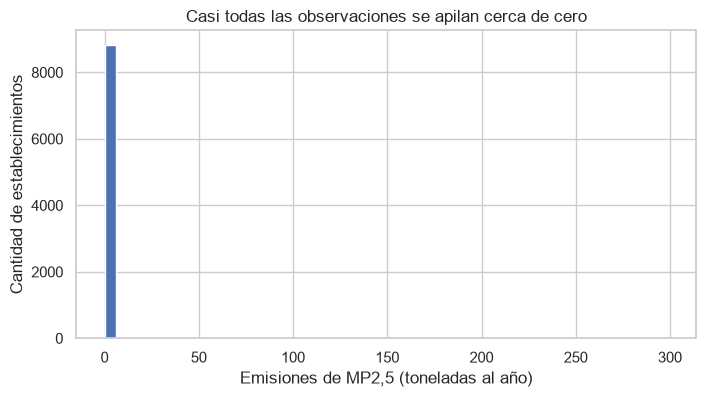

In [26]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(valores, bins=50, color="#4C72B0")
ax.set_xlabel("Emisiones de MP2,5 (toneladas al año)")
ax.set_ylabel("Cantidad de establecimientos")
ax.set_title("Casi todas las observaciones se apilan cerca de cero")
plt.show()

El histograma es casi ilegible: todo se aglomera en la primera barra. Esto pasa
siempre que la distribución es muy asimétrica.

Una solución habitual es mirar el eje en escala logarítmica, que separa los valores
pequeños y comprime los grandes.

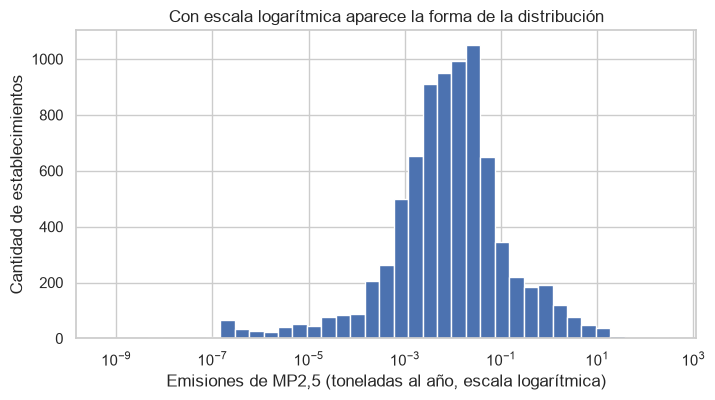

In [27]:
positivos = valores[valores > 0]

# Los intervalos también tienen que ser logarítmicos. Si se dejan lineales, todas las
# observaciones caen en la primera barra y el gráfico sigue sin leerse.
intervalos = np.logspace(np.log10(positivos.min()), np.log10(positivos.max()), 40)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(positivos, bins=intervalos, color="#4C72B0")
ax.set_xscale("log")
ax.set_xlabel("Emisiones de MP2,5 (toneladas al año, escala logarítmica)")
ax.set_ylabel("Cantidad de establecimientos")
ax.set_title("Con escala logarítmica aparece la forma de la distribución")
plt.show()

Ahora sí se ve la forma: la mayoría de los establecimientos se concentra en torno a
unas milésimas de tonelada, y hay una cola larga hacia la derecha.

Note dos cosas que hubo que cuidar. Primero, sacamos los ceros, porque el logaritmo de
cero no está definido. Segundo, no basta con poner el eje en escala logarítmica: los
intervalos del histograma también deben serlo, si no todo vuelve a caer en una sola
barra. Toda transformación tiene ese tipo de costo y conviene declararlo.

Sobre este mismo gráfico podemos marcar la media y la mediana.

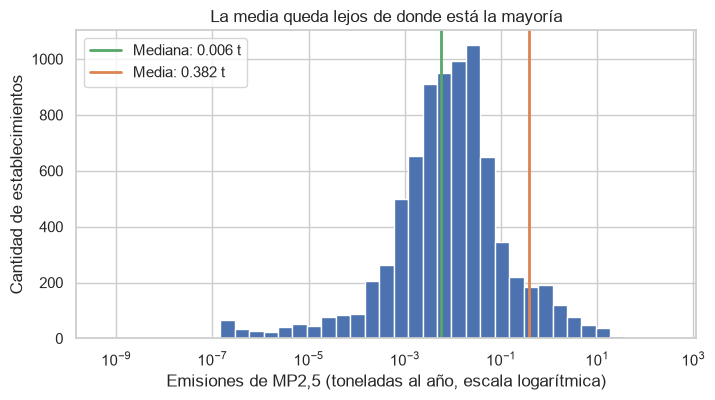

In [28]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(positivos, bins=intervalos, color="#4C72B0")
ax.set_xscale("log")
ax.axvline(mediana, color="#55A868", linewidth=2, label=f"Mediana: {mediana:.3f} t")
ax.axvline(media, color="#DD8452", linewidth=2, label=f"Media: {media:.3f} t")
ax.set_xlabel("Emisiones de MP2,5 (toneladas al año, escala logarítmica)")
ax.set_ylabel("Cantidad de establecimientos")
ax.set_title("La media queda lejos de donde está la mayoría")
ax.legend()
plt.show()

La mediana cae justo donde se acumulan los datos. La media, en cambio, queda a la
derecha del grueso de las observaciones: describe un establecimiento que casi no
existe.

El **diagrama de caja** resume la distribución con la mediana, los cuartiles y los
valores extremos. Sirve muy bien para comparar grupos.

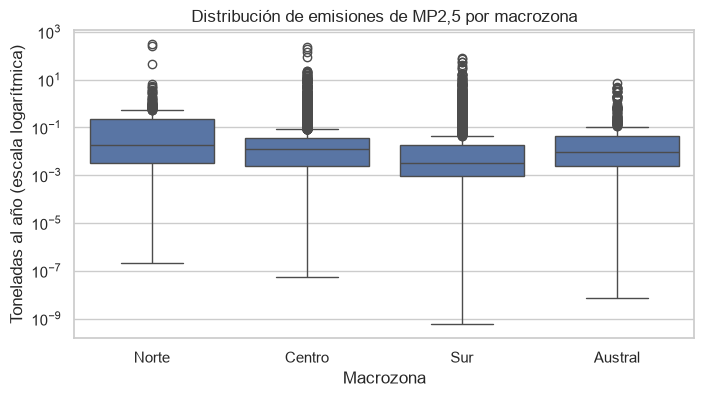

In [29]:
zonas_orden = ["Norte", "Centro", "Sur", "Austral"]
datos_zona = mp25_zonas[mp25_zonas["cantidad_toneladas"] > 0]

fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(
    data=datos_zona, x="macrozona", y="cantidad_toneladas",
    order=zonas_orden, ax=ax, color="#4C72B0",
)
ax.set_yscale("log")
ax.set_xlabel("Macrozona")
ax.set_ylabel("Toneladas al año (escala logarítmica)")
ax.set_title("Distribución de emisiones de MP2,5 por macrozona")
plt.show()

Finalmente, un gráfico de barras para comparar totales entre categorías. Las barras
ordenadas de mayor a menor se leen mucho más rápido que en orden alfabético.

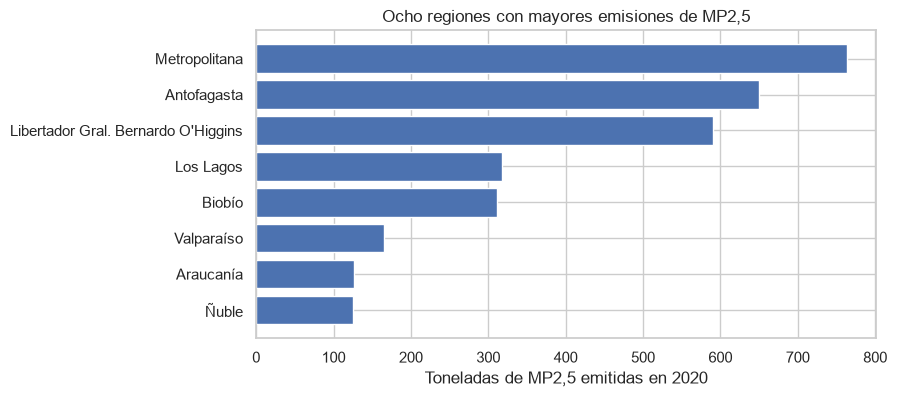

In [30]:
top_regiones = por_region.head(8)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(top_regiones.index, top_regiones.values, color="#4C72B0")
ax.invert_yaxis()
ax.set_xlabel("Toneladas de MP2,5 emitidas en 2020")
ax.set_title("Ocho regiones con mayores emisiones de MP2,5")
plt.show()

## 8. Síntesis

- Un **DataFrame** es una tabla; una **Series** es una columna.
- Antes de calcular, mire `shape`, `info()` y los datos faltantes.
- `loc` selecciona por etiqueta y `iloc` por posición.
- Los filtros se construyen con condiciones booleanas, combinadas con `&` y `|`.
- `groupby` más una función de resumen responde la mayoría de las preguntas
  descriptivas.
- Después de un `merge`, revise siempre si quedaron filas sin pareja.
- Cuando la distribución es asimétrica, el promedio describe mal el caso típico. La
  mediana y los percentiles son más honestos.

## 9. Para practicar

Responda usando el mismo archivo de datos.

1. ¿Cuántas comunas distintas aparecen en el conjunto de datos?
2. Calcule el total de MP10 por región y compare el ranking con el de MP2,5.
   ¿Cambian las primeras posiciones?
3. Obtenga los cinco establecimientos con mayores emisiones de SO2. ¿A qué rubro
   pertenecen?
4. La media truncada al 10% de MP2,5 sigue siendo bastante mayor que la mediana.
   ¿Qué le dice eso sobre la distribución?

## Referencias

- Bruce, P., Bruce, A. y Gedeck, P. (2020). *Practical Statistics for Data Scientists*,
  2ª ed. O'Reilly. Capítulo 1, "Exploratory Data Analysis". Notebooks disponibles en
  https://github.com/gedeck/practical-statistics-for-data-scientists
- VanderPlas, J. (2016). *Python Data Science Handbook*. Capítulo 3, "Data Manipulation
  with Pandas". https://jakevdp.github.io/PythonDataScienceHandbook/
- Ministerio del Medio Ambiente. Registro de Emisiones y Transferencias de
  Contaminantes (RETC). https://datosretc.mma.gob.cl